# Exploratory Data Analysis

In [1]:
# import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os

In [2]:
# import data and merge
months = ['jan', 'feb', 'mar', 'apr', 'may']

data_dir = '../data/'

# create first pd df with Dec data and store in list
dfs = [pd.read_csv(os.path.join(data_dir, 'CRMLSSold202512.csv'))]

# append the other months
for idx, month in enumerate(months):
    file_path = os.path.join(data_dir, f'CRMLSSold20260{idx+1}.csv')
    dfs.append(pd.read_csv(file_path))

# merge together
data = pd.concat(dfs, ignore_index=True)

/var/folders/zr/3bj1t2vd2klbq4dnl21sqz7m0000gn/T/ipykernel_23072/2984293073.py:12: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(file_path))


I will deal with the mixed data types in the `WaterfrontYN` and `PostalCode` columns next week when we work on data preprocessing. After a quick inspection, The mixed data types in `PostalCode` comes from some ZIP codes only being 5 digits long while others are 9 digits, with the last 4 being an extension, separated by a hyphen while the `WaterfrontYN` column is missing 99.9% of its observations. For the analysis, I will be dropping the ZIP code extensions and dropping the `WaterfrontYN` column.

In [3]:
# inspect first few rows
data.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,ContraCosta,ContraCosta,"Carpet,Tile,Wood",NaN,NaN,NaN,False,1998000.0,1150041639,teresa@teresahooper.com,...,NaN,10080.0,NaN,False,3.0,San Ramon Valley,94596,975.0,10080.0,NaN
1,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1150038872,homes@roomsantacruz.com,...,NaN,5663.0,NaN,NaN,5.0,Other,95018,NaN,5663.0,NaN
2,SanDiego,SanDiego,"Carpet,Wood",True,NaN,NaN,False,2214421.0,1150038683,laura@lauralothianrealestate.com,...,NaN,34745.0,NaN,False,3.0,NaN,91364,NaN,34745.0,NaN
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,1200000.0,1150038607,trung.lam@kw.com,...,NaN,6600.0,NaN,False,2.0,Other,95121,NaN,6600.0,NaN
4,TriCounties,TriCounties,NaN,True,NaN,NaN,True,3300.0,1150038314,c21themvpteam@gmail.com,...,NaN,17500.0,4.0,False,2.0,Jurupa Unified,92509,0.0,17500.0,NaN


In [4]:
# verify six months of data
data['CloseDate'] = pd.to_datetime(data['CloseDate'])

print(data['CloseDate'].min())
print(data['CloseDate'].max())

data['CloseDate'].dt.to_period('M').value_counts().sort_index()

2025-12-01 00:00:00
2026-05-31 00:00:00


CloseDate
2025-12    20538
2026-01    16487
2026-02    18124
2026-03    22583
2026-04    23412
2026-05    23260
Freq: M, Name: count, dtype: int64

In [5]:
# restrict analysis to PropertyType = Residential and PropertySubType = SingleFamilyResidence
data_res = data[
    (data.PropertyType == 'Residential') & (data.PropertySubType == 'SingleFamilyResidence')
].copy()

data_res.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,ContraCosta,ContraCosta,"Carpet,Tile,Wood",NaN,NaN,NaN,False,1998000.0,1150041639,teresa@teresahooper.com,...,NaN,10080.0,NaN,False,3.0,San Ramon Valley,94596,975.0,10080.0,NaN
2,SanDiego,SanDiego,"Carpet,Wood",True,NaN,NaN,False,2214421.0,1150038683,laura@lauralothianrealestate.com,...,NaN,34745.0,NaN,False,3.0,NaN,91364,NaN,34745.0,NaN
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,1200000.0,1150038607,trung.lam@kw.com,...,NaN,6600.0,NaN,False,2.0,Other,95121,NaN,6600.0,NaN
7,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,3100000.0,1150032869,vickie@realsmartgroup.com,...,NaN,8262.0,NaN,False,1.0,San Jose Unified,95124,NaN,8262.0,NaN
9,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,2900000.0,1150028403,vickie@realsmartgroup.com,...,NaN,9222.0,NaN,False,2.0,Other,95128,NaN,9222.0,NaN


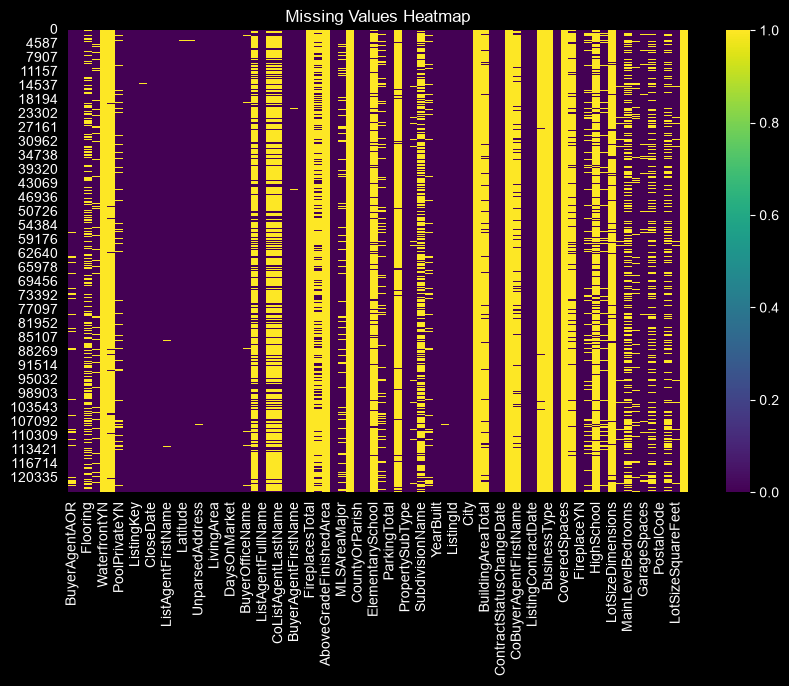

In [6]:
# visualize missing data
plt.figure(figsize=(10, 6))
sns.heatmap(data_res.isnull(), cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

The displayed variables are only a subset of the ones included in the dataset. Already, we can see a non-negligible amount of missing data. I will work on this next week during our data preprocessing. Next, I will inspect the distribution of some important variables we will use for analysis.

## Close Price

We begin by inspecting the distribution of the target variable in our data set, the close price.

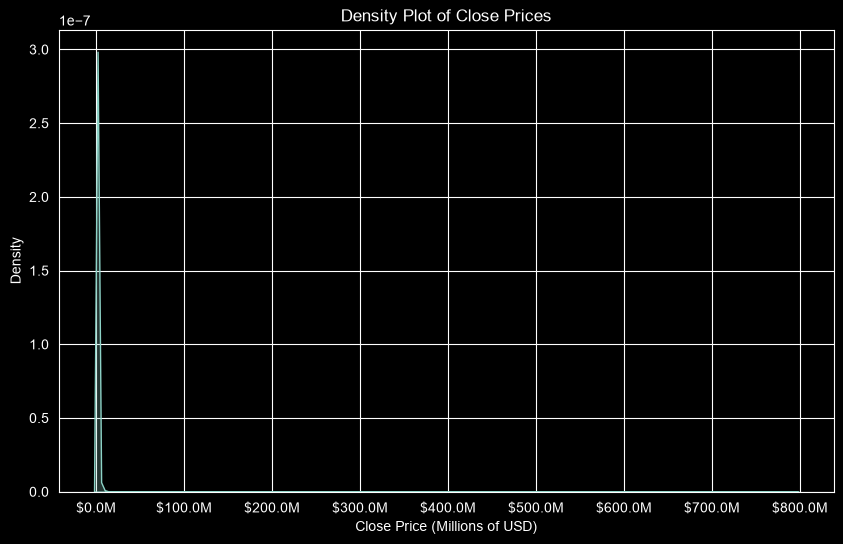

In [7]:
# plot density of Close Price
plt.figure(figsize=(10, 6))
sns.kdeplot(data_res['ClosePrice'], fill=True)
plt.title('Density Plot of Close Prices')
plt.xlabel('Close Price (Millions of USD)')
plt.ylabel('Density')

ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'${x/1_000_000:.1f}M'))

plt.show()

The plot is heavily skewed. This is likely due to outliers in the data. We can remove the largest outliers to observe how the distribution shifts.

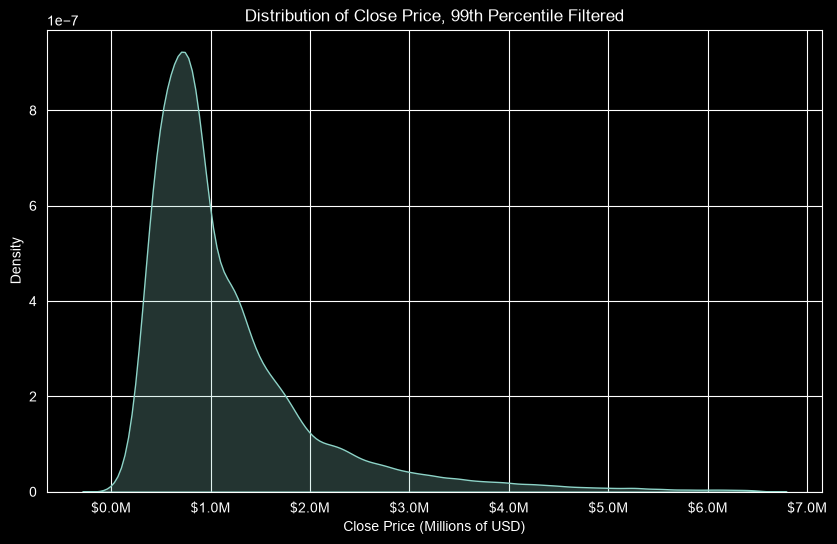

In [8]:
# filter the dataframe from outliers for plotting
cutoff = data_res['ClosePrice'].quantile(0.99)
filtered_data = data_res[data_res['ClosePrice'] <= cutoff]

# plot
plt.figure(figsize=(10, 6))
sns.kdeplot(filtered_data['ClosePrice'], fill=True)
plt.title('Distribution of Close Price, 99th Percentile Filtered')
plt.xlabel('Close Price (Millions of USD)')
plt.ylabel('Density')

ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'${x/1_000_000:.1f}M'))

plt.show()

After removing the largest outliers in the data, we observe a significant difference in the density plot. This will be important for the data preprocessing as there will definitely need to be an added layer of outlier analysis before we can decide to drop them. We can also consider transformations to this column.

In [9]:
# regular data info
data_res.ClosePrice.describe()

count    6.172700e+04
mean     1.340106e+06
std      7.307629e+06
min      1.750000e+00
25%      6.200000e+05
50%      8.900000e+05
75%      1.425000e+06
max      7.960000e+08
Name: ClosePrice, dtype: float64

In [10]:
# data with outliers removed info
filtered_data.ClosePrice.describe()

count    6.111800e+04
mean     1.166392e+06
std      8.832861e+05
min      1.750000e+00
25%      6.180000e+05
50%      8.850000e+05
75%      1.400000e+06
max      6.500000e+06
Name: ClosePrice, dtype: float64

The minimum value for `ClosePrice` is 1.75. This is a very abnormal number for this column, we will have to investigate this further in our data preprocessing step.

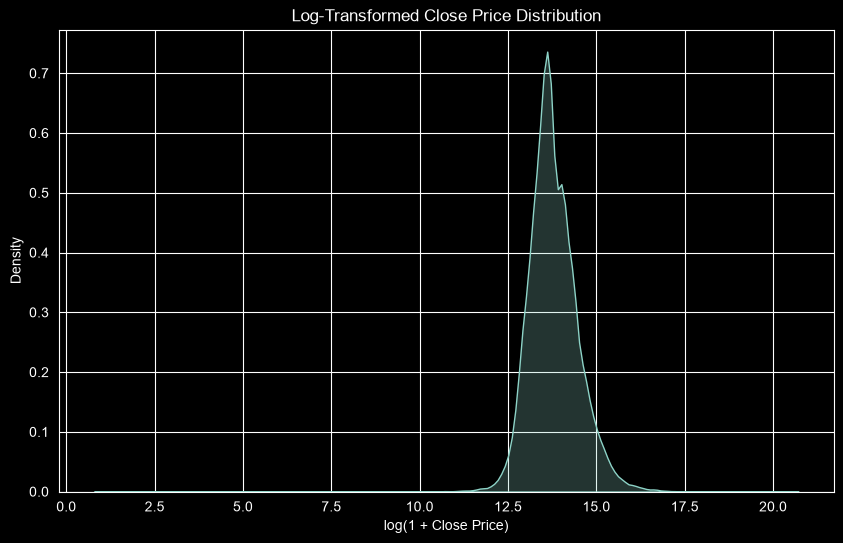

In [11]:
# apply log transformation and re-plot
plt.figure(figsize=(10, 6))
data_res['log_ClosePrice'] = np.log1p(data_res['ClosePrice'])
sns.kdeplot(data_res['log_ClosePrice'], fill=True)
plt.title('Log-Transformed Close Price Distribution')
plt.xlabel('log(1 + Close Price)')
plt.ylabel('Density')
plt.show()

In [12]:
# inspect missingness
data_res.ClosePrice.isnull().mean()

np.float64(0.0)

## Living Area

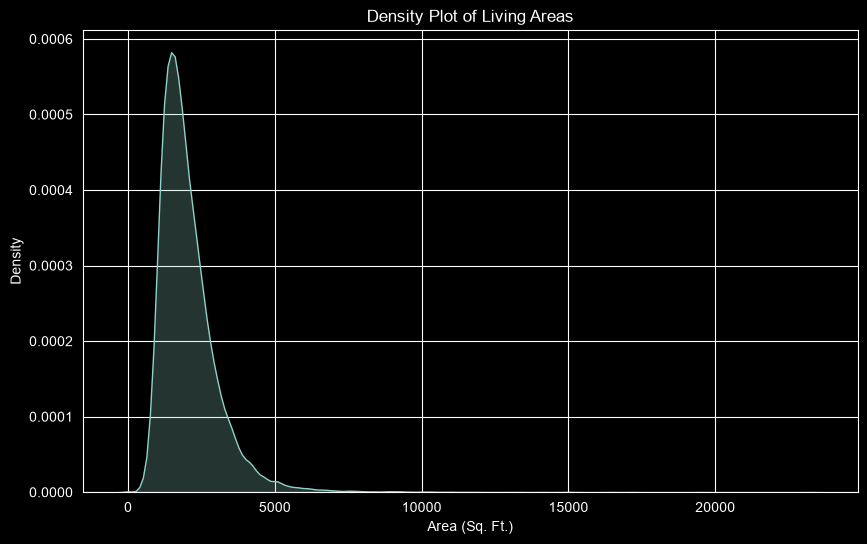

In [13]:
# plot density of Living Area
plt.figure(figsize=(10, 6))
sns.kdeplot(data_res['LivingArea'], fill=True)
plt.title('Density Plot of Living Areas')
plt.xlabel('Area (Sq. Ft.)')
plt.ylabel('Density')
plt.show()

The dataset does not include unit metadata directly in the column name, but the observed values align with typical residential square footage, so I'll treat this column as square feet for EDA.

In [14]:
data_res.LivingArea.describe()

count    61697.000000
mean      2055.552918
std       1037.243701
min          0.000000
25%       1386.000000
50%       1826.000000
75%       2455.000000
max      23314.000000
Name: LivingArea, dtype: float64

The minimum value for `LivingArea` is 0, which is not realistic for a residential property. This may indicate missing or placeholder values and will be handled during preprocessing.

In [15]:
# inspect missingness
data_res.LivingArea.isnull().mean()

np.float64(0.00048601098384823497)

## Bedrooms

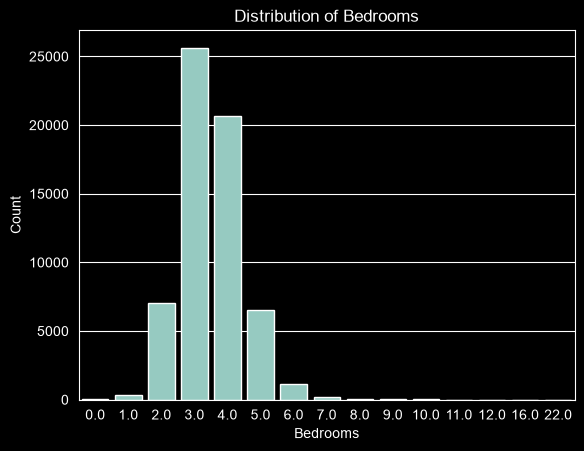

In [16]:
# plot density of bedrooms
sns.countplot(x='BedroomsTotal', data=data_res)
plt.title('Distribution of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Count')
plt.show()

In [17]:
data_res.BedroomsTotal.describe()

count    61727.000000
mean         3.498437
std          0.966684
min          0.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         22.000000
Name: BedroomsTotal, dtype: float64

In [18]:
# inspect missingness
data_res.BedroomsTotal.isnull().mean()

np.float64(0.0)

## Bathrooms

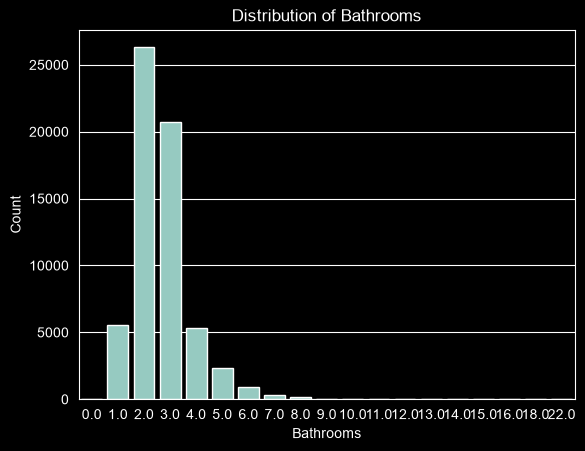

In [19]:
# plot density of bathrooms
sns.countplot(x='BathroomsTotalInteger', data=data_res)
plt.title('Distribution of Bathrooms')
plt.xlabel('Bathrooms')
plt.ylabel('Count')
plt.show()

In [20]:
data_res.BathroomsTotalInteger.describe()

count    61726.000000
mean         2.644801
std          1.135026
min          0.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         22.000000
Name: BathroomsTotalInteger, dtype: float64

In [21]:
# inspect missingness
data_res.BathroomsTotalInteger.isnull().mean()

np.float64(1.62003661282745e-05)

## Lot Size

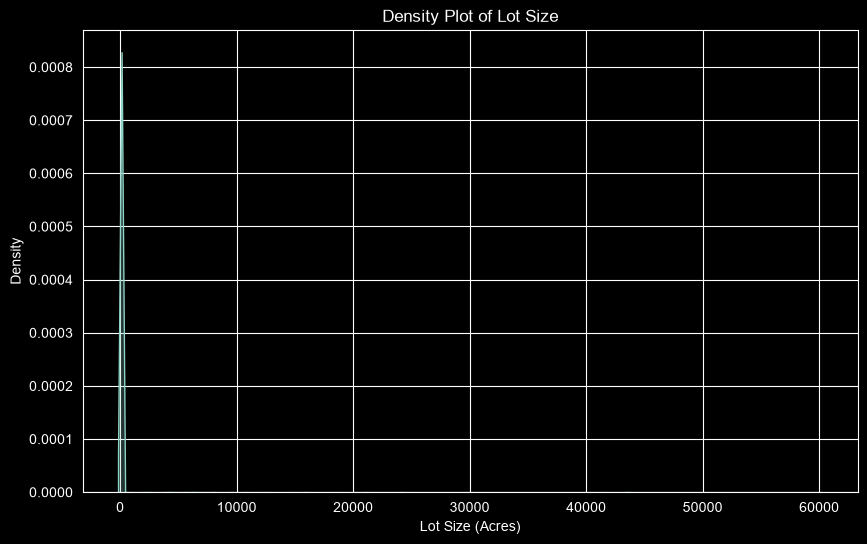

In [22]:
# plot density of lot size, use acres to standardize units
plt.figure(figsize=(10, 6))
sns.kdeplot(data_res['LotSizeAcres'], fill=True)
plt.title('Density Plot of Lot Size')
plt.xlabel('Lot Size (Acres)')
plt.ylabel('Density')
plt.show()

`LotSizeAcres` is heavily right-skewed. The maximum is over 60,000 acres, which could be extremely large properties or possible data entry errors. Later preprocessing will investigate these  extreme values.

Text(0.5, 0, 'log(1 + Lot Size Acres)')

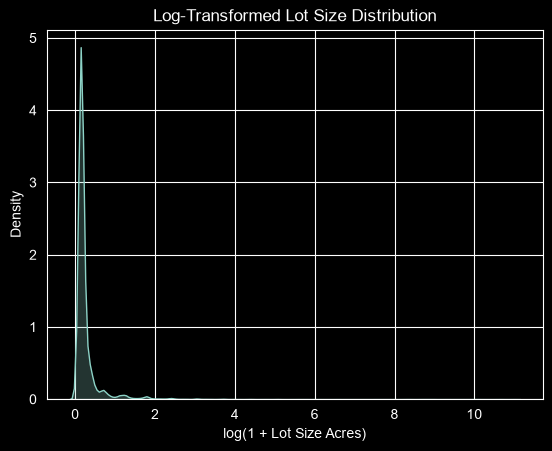

In [23]:
# apply log transformation and re-plot
data_res['log_LotSizeAcres'] = np.log1p(data_res['LotSizeAcres'])
sns.kdeplot(data_res['log_LotSizeAcres'], fill=True)
plt.title('Log-Transformed Lot Size Distribution')
plt.xlabel('log(1 + Lot Size Acres)')

In [24]:
data_res.LotSizeAcres.describe()

count    60644.000000
mean        10.828569
std        544.530184
min          0.000000
25%          0.130000
50%          0.166800
75%          0.240000
max      60113.000000
Name: LotSizeAcres, dtype: float64

In [25]:
# inspect missingness
data_res.LotSizeAcres.isnull().mean()

np.float64(0.017544996516921284)

## Additional Analyses

### Correlations Among Key Variables

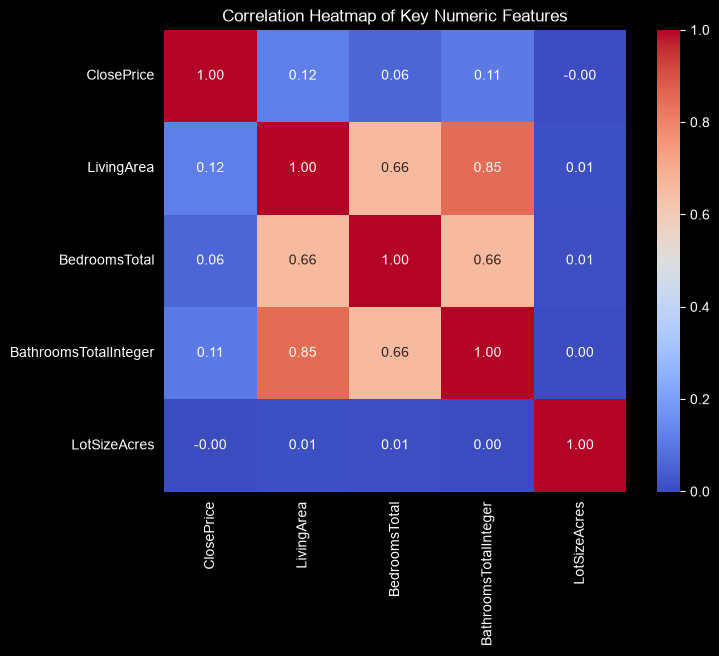

In [26]:
# list of features
eda_features = [
    'ClosePrice',
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LotSizeAcres'
]

# calculate correlations
corr_data = data_res[eda_features].copy()
corr_matrix = corr_data.corr()

# plot corelation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True
)
plt.title('Correlation Heatmap of Key Numeric Features')
plt.show()

The correlation matrix shows that `LivingArea`, `BedroomsTotal`, and `BathroomsTotalInteger` are strongly related to each other. This makes sense because larger homes usually have more rooms. However, `ClosePrice` has only weak correlations with these basic numeric features in this matrix. This tells us that the close price is likely influenced by other factors in the dataset. `LotSizeAcres` has almost no correlation with the other variables, likely because lot size is highly skewed and may need some preprocessing.

### Pairwise Relationships Among Key Features

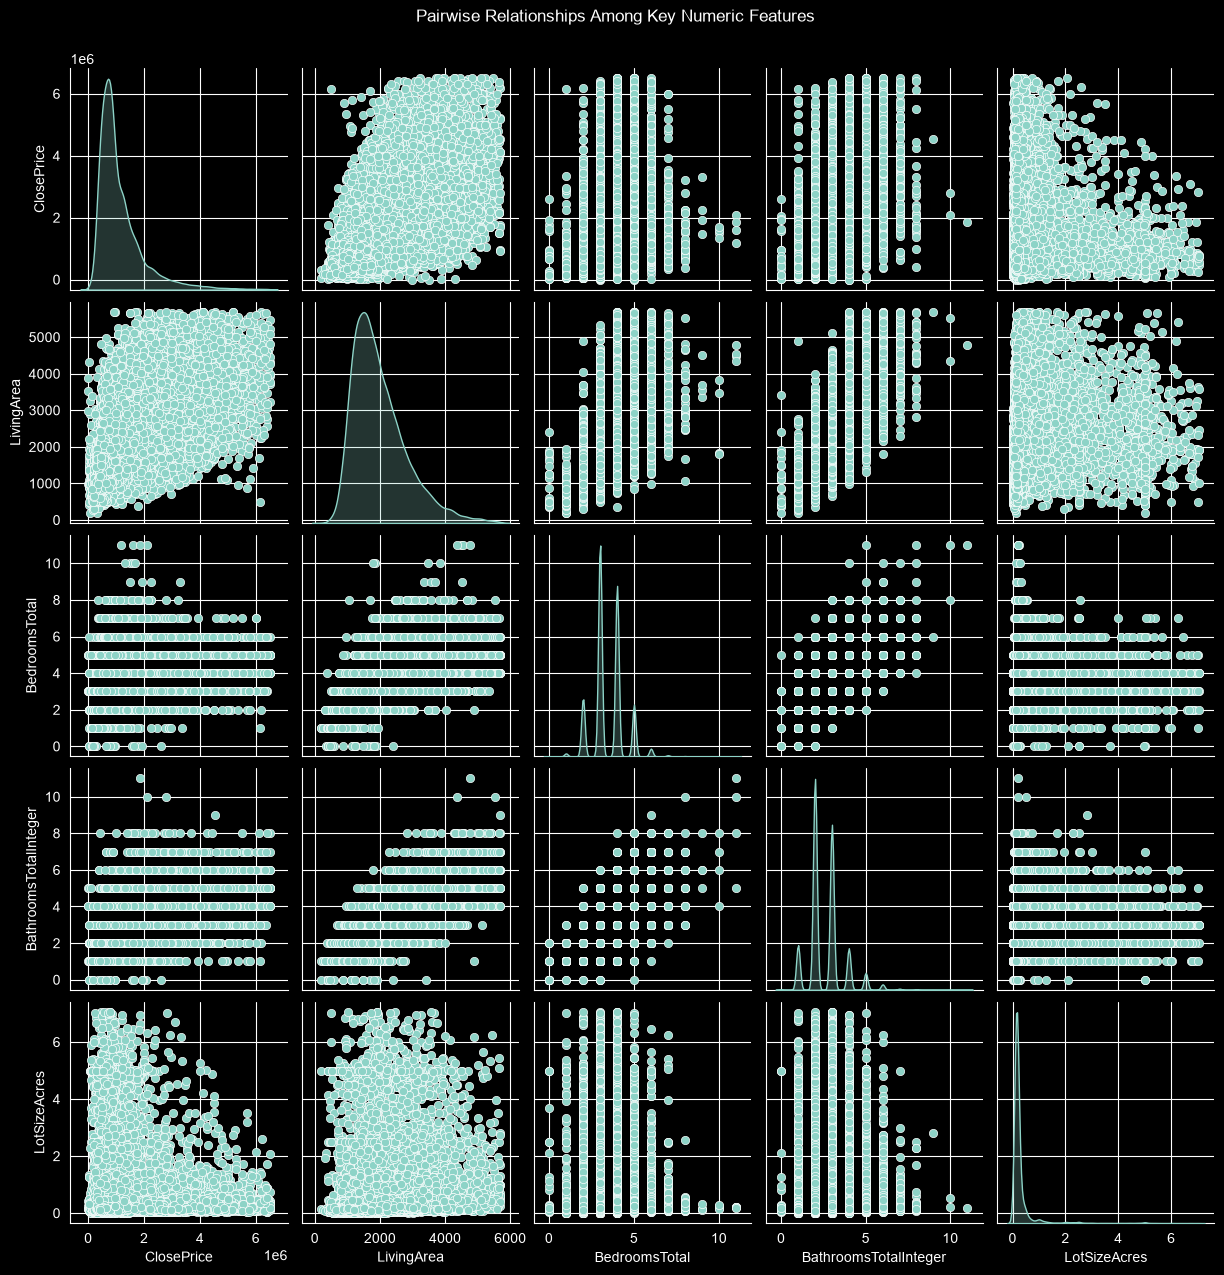

In [27]:
# list of features
pair_features = [
    'ClosePrice',
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LotSizeAcres'
]

# prepare data for plots, filter extreme values so the pairplot is readable
pair_data = data_res[pair_features].copy()
pair_data = pair_data[
    (pair_data['ClosePrice'] <= data_res['ClosePrice'].quantile(0.99)) &
    (pair_data['LivingArea'] <= data_res['LivingArea'].quantile(0.99)) &
    (pair_data['LotSizeAcres'] <= data_res['LotSizeAcres'].quantile(0.99)) &
    (pair_data['LivingArea'] > 0) &
    (pair_data['LotSizeAcres'] > 0)
]

# plot
sns.pairplot(pair_data, diag_kind='kde')
plt.suptitle('Pairwise Relationships Among Key Numeric Features', y=1.02)
plt.show()

The pair-plot shows pairwise relationships among the selected variables. `ClosePrice` appears to increase with `LivingArea`, and `LivingArea` is also related to `BedroomsTotal` and `BathroomsTotalInteger`. `LotSizeAcres` appears more skewed and less clearly related to `ClosePrice`.